
# Tutorial 5: **Matplotlib**
 
**Objetivo**: Crear visualizaciones básicas con **Matplotlib**, organizar figuras con **subplots**, y personalizar colores, marcadores y estilos.




<a id="material"></a>
## 1) Material de estudio



<a id="anatomia"></a>
### 1.1 Anatomía de una figura y primer gráfico

**Matplotlib** organiza los gráficos en una jerarquía:
- **Figure** (figura): el lienzo contenedor.
- **Axes** (ejes): el sistema de coordenadas donde se dibujan los datos.
- **Axis**, *ticks*, *labels*, **title**, **legend**: elementos que aportan contexto.

A continuación, creamos una figura simple y personalizamos lo básico.


Creando un gráfico de línea básico con títulos y etiquetas...


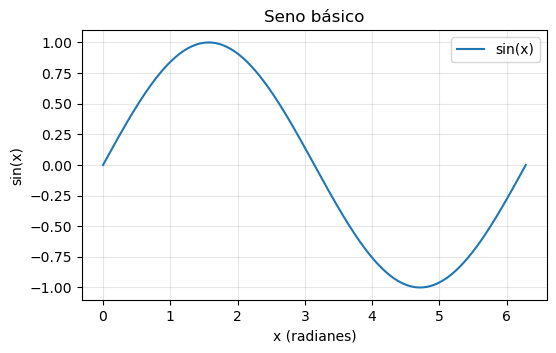

In [1]:

import matplotlib.pyplot as plt
import numpy as np

print("Creando un gráfico de línea básico con títulos y etiquetas...")

x = np.linspace(0, 2*np.pi, 200)
y = np.sin(x)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(x, y, label="sin(x)")
ax.set_title("Seno básico")
ax.set_xlabel("x (radianes)")
ax.set_ylabel("sin(x)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()


<a id="tipos"></a>
### 1.2 Tipos de gráficos básicos

Veremos cuatro tipos frecuentes:
- **Línea**: tendencias/series de tiempo.
- **Dispersión (scatter)**: relación entre dos variables.
- **Barras**: comparaciones por categoría.
- **Histograma**: distribución de una variable.


Ejemplo de gráficos básicos: línea, dispersión, barras e histograma.


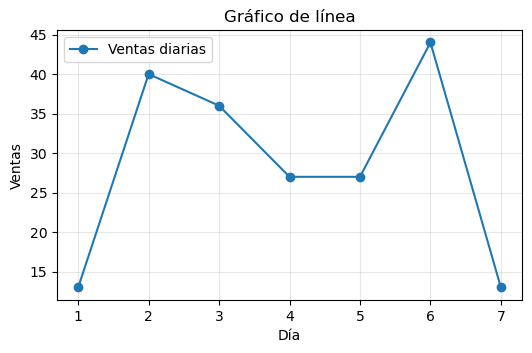

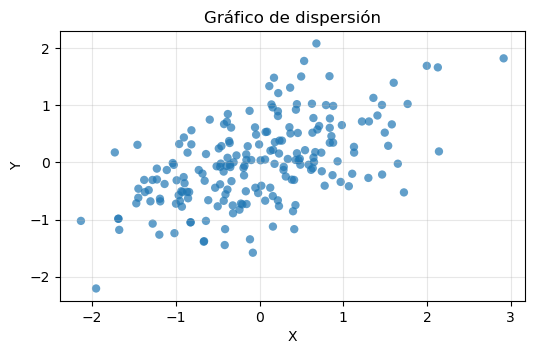

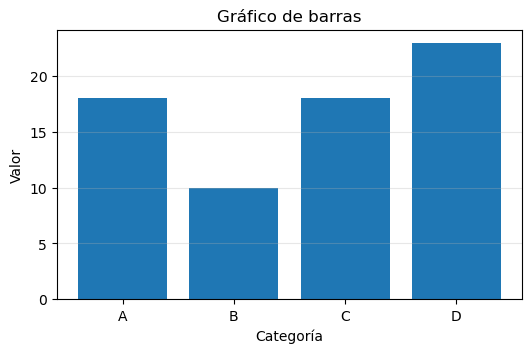

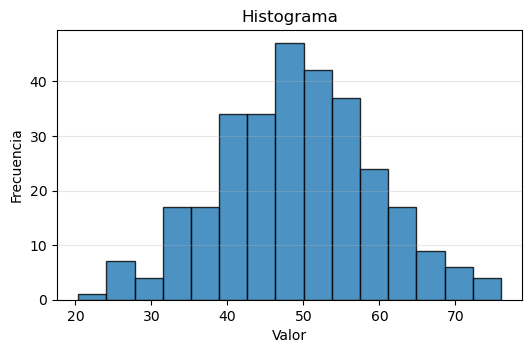

In [2]:

print("Ejemplo de gráficos básicos: línea, dispersión, barras e histograma.")

# Datos de ejemplo
rng = np.random.default_rng(42)
x = np.arange(1, 8)
ventas = rng.integers(10, 50, size=len(x))

# Línea
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(x, ventas, marker="o", label="Ventas diarias")
ax.set_title("Gráfico de línea")
ax.set_xlabel("Día")
ax.set_ylabel("Ventas")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

# Dispersión
x_sc = rng.normal(0, 1, 200)
y_sc = 0.5*x_sc + rng.normal(0, 0.6, 200)
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.scatter(x_sc, y_sc, alpha=0.7, edgecolor="none")
ax.set_title("Gráfico de dispersión")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.grid(True, alpha=0.3)
plt.show()

# Barras
categorias = ["A","B","C","D"]
valores = rng.integers(5, 25, size=len(categorias))
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(categorias, valores)
ax.set_title("Gráfico de barras")
ax.set_xlabel("Categoría")
ax.set_ylabel("Valor")
ax.grid(axis="y", alpha=0.3)
plt.show()

# Histograma
datos = rng.normal(50, 10, size=300)
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(datos, bins=15, edgecolor="black", alpha=0.8)
ax.set_title("Histograma")
ax.set_xlabel("Valor")
ax.set_ylabel("Frecuencia")
ax.grid(axis="y", alpha=0.3)
plt.show()


<a id="subplots-subfigures"></a>
### 1.3 Subplots vs Subfigures

- **Subplots**: cuadrículas de ejes dentro de una **misma figura**.
- **Subfigures** (*Matplotlib ≥ 3.4*): subdividen la **figura** en secciones independientes, cada una con su propio conjunto de ejes.

Abajo mostramos ambos enfoques. Si *subfigures* no está disponible en tu versión, caeremos automáticamente a **subplots**.


Versión de Matplotlib: 3.6.2
Creando subplots (2 columnas)...


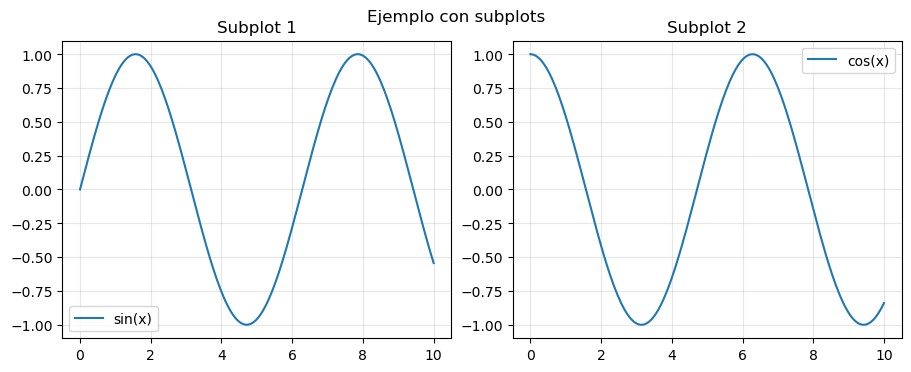

Intentando crear subfigures... (requiere Matplotlib >= 3.4)


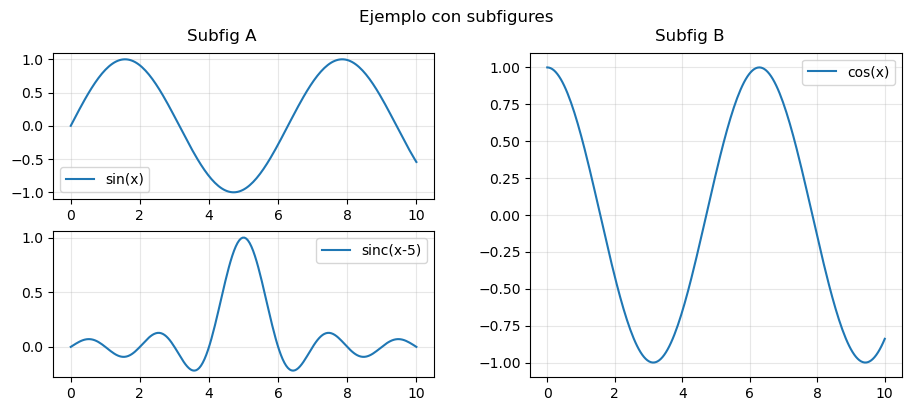

In [6]:

import matplotlib as mpl
print("Versión de Matplotlib:", mpl.__version__)

# SUBPLOTS clásicos
print("Creando subplots (2 columnas)...")
x = np.linspace(0, 10, 200)
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5), constrained_layout=True)

axes[0].plot(x, np.sin(x), label="sin(x)")
axes[0].set_title("Subplot 1")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(x, np.cos(x), label="cos(x)")
axes[1].set_title("Subplot 2")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.suptitle("Ejemplo con subplots", y=1.02)
plt.show()

# SUBFIGURES (si está disponible)
print("Intentando crear subfigures... (requiere Matplotlib >= 3.4)")
try:
    fig = plt.figure(figsize=(9, 3.8), constrained_layout=True)
    subfigs = fig.subfigures(1, 2, wspace=0.08)
    subfigs[0].suptitle("Subfig A")
    subfigs[1].suptitle("Subfig B")

    axA = subfigs[0].subplots(2, 1)
    axA[0].plot(x, np.sin(x), label="sin(x)")
    axA[0].legend(); axA[0].grid(True, alpha=0.3)
    axA[1].plot(x, np.sinc(x-5), label="sinc(x-5)")
    axA[1].legend(); axA[1].grid(True, alpha=0.3)

    axB = subfigs[1].subplots(1, 1)
    axB.plot(x, np.cos(x), label="cos(x)")
    axB.legend(); axB.grid(True, alpha=0.3)
    fig.suptitle("Ejemplo con subfigures", y=1.04)
    plt.show()
except Exception as e:
    print("No fue posible usar subfigures en esta versión. Motivo:", repr(e))
    print("Usa subplots como alternativa equivalente.")


<a id="custom"></a>
### 1.4 Personalización: colores, marcadores, estilos y fuentes

Algunos parámetros frecuentes:
- **color** (o `c`), **linestyle** (`'-'`, `'--'`, `':'`, `'-.'`), **linewidth**, **alpha**
- **marker** (`'o'`, `'^'`, `'s'`, `'*'`, etc.), **markersize**, **markeredgecolor**, **markerfacecolor**
- **grid**, **legend**, **ticks** rotados, **spines** ocultos o estilizados
- Estilos globales: `plt.style.use(...)`


Personalizando una figura con colores, marcadores y estilos...


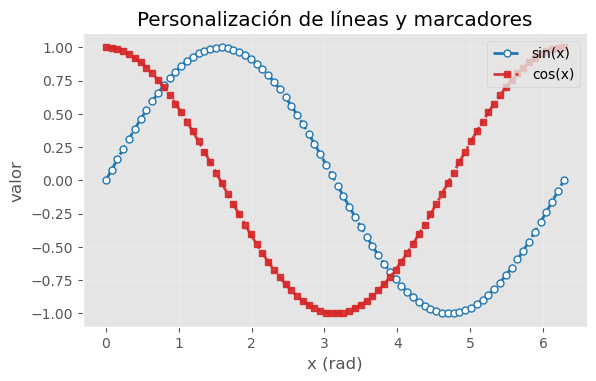

In [7]:
print("Personalizando una figura con colores, marcadores y estilos...")

x = np.linspace(0, 2*np.pi, 80)

plt.style.use("ggplot")  # estilo global (opcional)
fig, ax = plt.subplots(figsize=(6.5, 3.8))

ax.plot(x, np.sin(x), color="#1f77b4", linestyle="--", linewidth=2,
        marker="o", markersize=5, markerfacecolor="white", label="sin(x)")
ax.plot(x, np.cos(x), color="#d62728", linestyle="-.", linewidth=2,
        marker="s", markersize=5, alpha=0.9, label="cos(x)")

ax.set_title("Personalización de líneas y marcadores")
ax.set_xlabel("x (rad)")
ax.set_ylabel("valor")
ax.grid(True, alpha=0.2)
ax.legend(frameon=True, loc="upper right")
for spine in ["top","right"]:
    ax.spines[spine].set_visible(False)

plt.show()



<a id="savefig"></a>
### 1.5 Guardar figuras a archivos

Puedes exportar tus figuras con `fig.savefig(...)` (formatos comunes: PNG, SVG, PDF).  
Controla tamaño con `figsize` al crear la figura y resolución con `dpi` al guardar.


Guardando una figura en PNG y PDF...
Archivos guardados: figura_exportada.png y figura_exportada.pdf


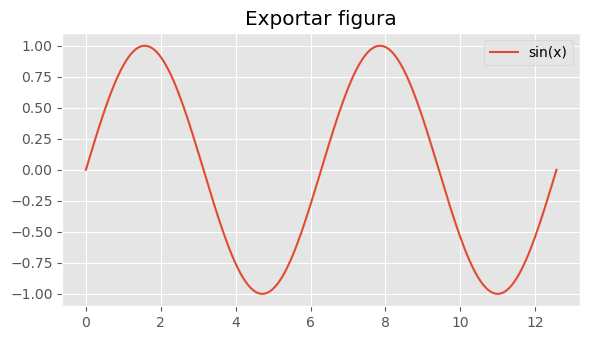

In [8]:

print("Guardando una figura en PNG y PDF...")

x = np.linspace(0, 4*np.pi, 200)
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(x, np.sin(x), label="sin(x)")
ax.set_title("Exportar figura")
ax.legend()
fig.tight_layout()

fig.savefig("figura_exportada.png", dpi=150)
fig.savefig("figura_exportada.pdf")
print("Archivos guardados: figura_exportada.png y figura_exportada.pdf")
plt.show()


<a id="ejercicios"></a>
## 2) Ejercicios

**Formato**: usa títulos, etiquetas de ejes, leyendas y **mensajes descriptivos** con `print(...)` para guiar la lectura del output.



### Ejercicio 1 — Serie temporal con marcadores
1. Carga `datasets_tutorial3/ventas.csv`. Si no está disponible, **simula** un DataFrame de ventas mensuales.  
2. Calcula ventas **mensuales** (suma por mes) y grafícalas con **línea + marcadores**.  
3. Personaliza: rotación de *ticks*, **grid**, anotación del mes con ventas **máximas**.


In [11]:
# Recordatorio como cargar clientes.csv
#import pandas as pd
#clientes_path = "datasets_tutorial3/clientes.csv"
#productos = pd.read_csv(productos_path)





### Ejercicio 2 — Subplots 2×2
Genera una figura con **4 subplots** (2×2) que contenga:  
- (1) Línea `sin(x)`  
- (2) Línea `cos(x)`  
- (3) Histograma de una normal `N(0,1)`  
- (4) Dispersión `(x, sin(x)+ruido)`  
Añade **títulos**, **leyendas** y **estilos** simples (marcadores, `linestyle`, etc.).



### Ejercicio 3 — Personalización de estilo
Elige **un gráfico de línea** y aplica:  
1) color personalizado (hex), 2) `linestyle` distinto, 3) marcador diferente, 4) `linewidth` y `alpha`,  
5) **leyenda** con borde, 6) quita `spines` superior y derecho.
